<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/OSA/OSA_Using_Evolutionary_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

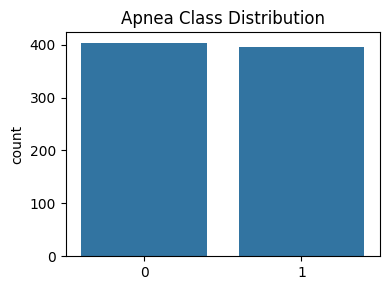

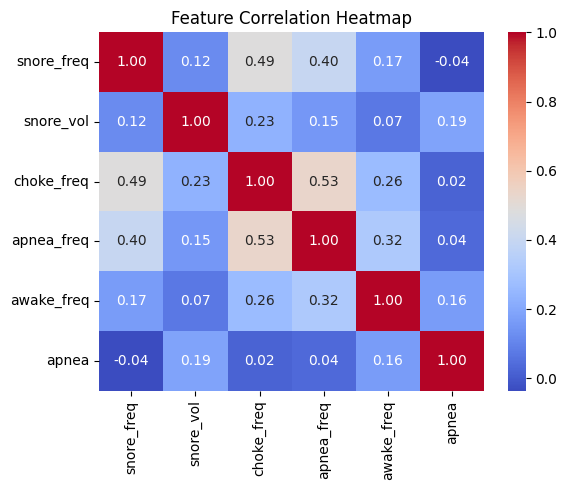

In [29]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

# Create folder for figures
import os
os.makedirs("figures", exist_ok=True)

# ==========================================================
# 2. USER-TUNABLE PARAMETERS
# ==========================================================
N_HIDDEN = 30
POP_SIZE = 30
ITERATIONS = 150
CROSS_RATE = 0.65
MUT_RATE = 0.001

# PSO parameters
W = 0.5
C1 = 1.5
C2 = 1.5

# ==========================================================
# 3. LOAD & PREPROCESS DATA
# ==========================================================
df = pd.read_csv("sleep_disordered_breathing.csv")

X = df.drop(columns=["apnea"]).values
y = df["apnea"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. DATA VISUALIZATION
# ==========================================================
plt.figure(figsize=(4,3))
sns.countplot(x=y)
plt.title("Apnea Class Distribution")
plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)
plt.show()


In [30]:
# ==========================================================
# 5. ANN MODEL & FITNESS (MSE-based)
# ==========================================================
def ann_forward(X, weights):
    w1, b1, w2, b2 = weights
    a1 = np.tanh(X @ w1 + b1)
    z2 = np.clip(a1 @ w2 + b2, -20, 20)
    return 1 / (1 + np.exp(-z2))

def decode_weights(vec, n_in, n_h):
    idx = 0
    w1 = vec[idx:idx+n_in*n_h].reshape(n_in, n_h)
    idx += n_in*n_h
    b1 = vec[idx:idx+n_h]
    idx += n_h
    w2 = vec[idx:idx+n_h].reshape(n_h,1)
    idx += n_h
    b2 = vec[idx]
    return w1, b1, w2, b2

DIM = X_train.shape[1]*N_HIDDEN + N_HIDDEN + N_HIDDEN + 1

def fitness(pop):
    f = np.zeros(len(pop))
    for i, ind in enumerate(pop):
        w = decode_weights(ind, X_train.shape[1], N_HIDDEN)
        y_hat = ann_forward(X_train, w).flatten()
        f[i] = np.mean((y_train - y_hat)**2)
    return f

# ==========================================================
# 6. GENETIC ALGORITHM (GA)
# ==========================================================
def GA():
    pop = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    history = []

    for _ in range(ITERATIONS):
        fit = fitness(pop)
        history.append(np.min(fit))

        elite = pop[np.argsort(fit)[:int(0.2*POP_SIZE)]]
        children = []

        while len(children) < POP_SIZE - len(elite):
            p1, p2 = elite[np.random.choice(len(elite), 2, replace=False)]
            if np.random.rand() < CROSS_RATE:
                pt = np.random.randint(1, DIM)
                c = np.concatenate([p1[:pt], p2[pt:]])
            else:
                c = p1.copy()
            if np.random.rand() < MUT_RATE:
                c += 0.1 * np.random.randn(DIM)
            children.append(c)

        pop = np.vstack([elite] + children)

    return pop[np.argmin(fitness(pop))], history

# ==========================================================
# 7. PARTICLE SWARM OPTIMIZATION (PSO)
# ==========================================================
def PSO():
    pop = np.random.uniform(-1,1,(POP_SIZE,DIM))
    vel = np.zeros_like(pop)
    pbest = pop.copy()
    pbest_fit = fitness(pop)
    gbest = pbest[np.argmin(pbest_fit)]
    history = []

    for _ in range(ITERATIONS):
        fit = fitness(pop)
        history.append(np.min(fit))

        for i in range(POP_SIZE):
            if fit[i] < pbest_fit[i]:
                pbest[i], pbest_fit[i] = pop[i].copy(), fit[i]

        gbest = pbest[np.argmin(pbest_fit)]
        vel = W*vel + C1*np.random.rand(*vel.shape)*(pbest-pop) \
                    + C2*np.random.rand(*vel.shape)*(gbest-pop)
        pop += vel

    return gbest, history

# ==========================================================
# 8. CROW SEARCH ALGORITHM (CSA)
# ==========================================================
def CSA():
    crows = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    memory = crows.copy()
    history = []

    for _ in range(ITERATIONS):
        fit = fitness(crows)
        history.append(np.min(fit))
        best = crows[np.argmin(fit)]

        for i in range(POP_SIZE):
            if np.random.rand() < 0.8:
                crows[i] += np.random.rand() * (best - memory[i])
            else:
                crows[i] = np.random.uniform(-1, 1, DIM)
        memory = crows.copy()

    return best, history

# ==========================================================
# 9. TRAIN MODELS
# ==========================================================
best_ga, hist_ga = GA()
best_pso, hist_pso = PSO()
best_csa, hist_csa = CSA()



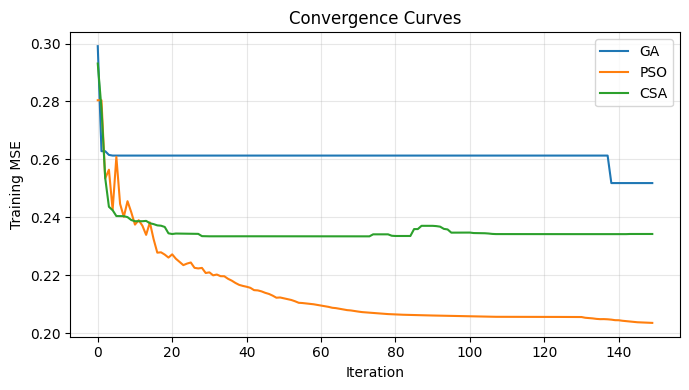

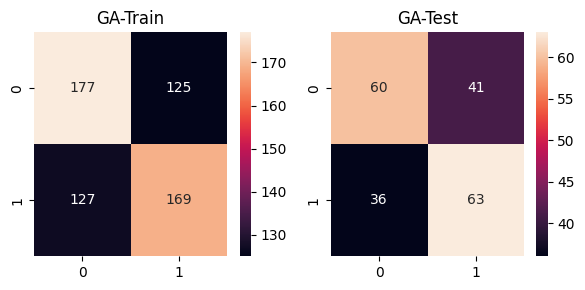

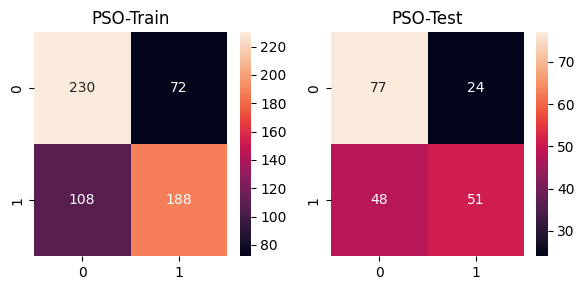

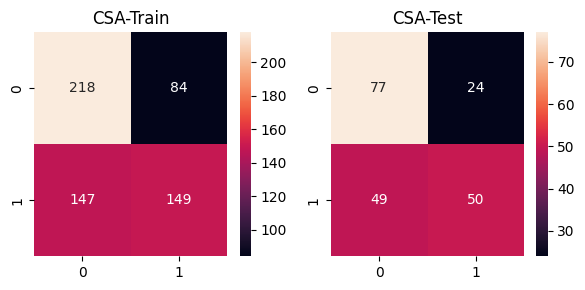

,GA-Train,GA-Test,PSO-Train,PSO-Test,CSA-Train,CSA-Test
Accuracy,0.578595,0.615000,0.698997,0.640000,0.613712,0.635000
Precision,0.574830,0.605769,0.723077,0.680000,0.639485,0.675676
Recall,0.570946,0.636364,0.635135,0.515152,0.503378,0.505051
F1-score,0.572881,0.620690,0.676259,0.586207,0.563327,0.578035


In [31]:
# ==========================================================
# 10. CONVERGENCE CURVES (MSE)
# ==========================================================
plt.figure(figsize=(7,4))
plt.plot(hist_ga, label="GA")
plt.plot(hist_pso, label="PSO")
plt.plot(hist_csa, label="CSA")
plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("Convergence Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/convergence_curves.png", dpi=300)
plt.show()

# ==========================================================
# 11. EVALUATION + CONFUSION MATRICES
# ==========================================================
def evaluate(best, name):
    w = decode_weights(best, X_train.shape[1], N_HIDDEN)
    ytr = (ann_forward(X_train, w).flatten() > 0.5).astype(int)
    yte = (ann_forward(X_test, w).flatten() > 0.5).astype(int)

    fig, ax = plt.subplots(1,2,figsize=(6,3))
    sns.heatmap(confusion_matrix(y_train,ytr),annot=True,fmt="d",ax=ax[0])
    sns.heatmap(confusion_matrix(y_test,yte),annot=True,fmt="d",ax=ax[1])
    ax[0].set_title(f"{name}-Train")
    ax[1].set_title(f"{name}-Test")
    plt.tight_layout()
    plt.savefig(f"figures/confusion_{name}.png", dpi=300)
    plt.show()

    return ytr, yte

preds = {
    "GA": evaluate(best_ga,"GA"),
    "PSO": evaluate(best_pso,"PSO"),
    "CSA": evaluate(best_csa,"CSA")
}

# ==========================================================
# 12. RESULTS TABLE
# ==========================================================
metrics = ["Accuracy","Precision","Recall","F1-score"]
table = {}

for algo,(ytr,yte) in preds.items():
    table[f"{algo}-Train"] = [
        accuracy_score(y_train,ytr),
        precision_score(y_train,ytr),
        recall_score(y_train,ytr),
        f1_score(y_train,ytr)
    ]
    table[f"{algo}-Test"] = [
        accuracy_score(y_test,yte),
        precision_score(y_test,yte),
        recall_score(y_test,yte),
        f1_score(y_test,yte)
    ]

df_results = pd.DataFrame(table,index=metrics)
df_results
# df_results.to_csv("results_metrics.csv")


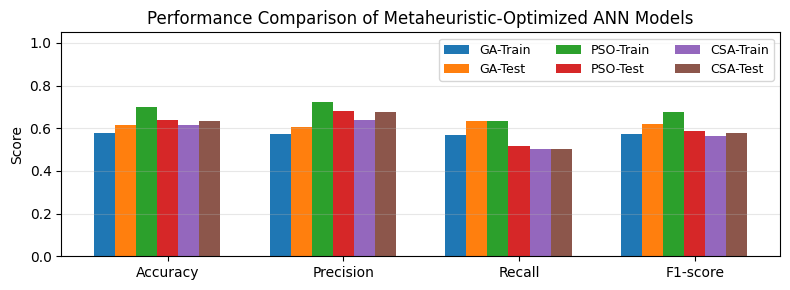

In [32]:

# ==========================================================
# 13. GROUPED BAR CHART (TRAIN vs TEST)
# ==========================================================
x = np.arange(len(metrics))
width = 0.12

plt.figure(figsize=(8,3))
for i,col in enumerate(df_results.columns):
    plt.bar(x+i*width, df_results[col], width, label=col)

plt.xticks(x+width*3, metrics)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Performance Comparison of Metaheuristic-Optimized ANN Models")
plt.legend(ncol=3, fontsize=9)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/performance_bar_chart.png", dpi=300)
plt.show()


In [33]:
import pickle

model = {
    "weights": best_pso,                 # already optimized weights
    "scaler": scaler,                    # fitted scaler
    "feature_names": list(df.drop(columns=["apnea"]).columns),
    "hidden_neurons": N_HIDDEN,
    "train_accuracy": accuracy_score(y_train, preds["PSO"][0]),
    "test_accuracy": accuracy_score(y_test, preds["PSO"][1])
}

with open("pso_ann_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("PSO-ANN model saved successfully.")


PSO-ANN model saved successfully.


In [38]:
import pickle
import numpy as np

with open("pso_ann_model.pkl", "rb") as f:
    model = pickle.load(f)

def ann_predict(x):
    w = model["weights"]
    scaler = model["scaler"]
    n_h = model["hidden_neurons"]
    n_in = len(model["feature_names"])

    x = scaler.transform([x])

    i = 0
    w1 = w[i:i+n_in*n_h].reshape(n_in, n_h)
    i += n_in*n_h
    b1 = w[i:i+n_h]
    i += n_h
    w2 = w[i:i+n_h].reshape(n_h,1)
    i += n_h
    b2 = w[i]

    a1 = np.tanh(x @ w1 + b1)
    prob = 1/(1+np.exp(-(a1 @ w2 + b2)))

    return prob[0][0]

# Example input
sample = [9, 9, 1, 9, 1]   # snore_freq, snore_vol, ...
p = ann_predict(sample)

print("Apnea" if p > 0.5 else "No Apnea", "Confidence:", round(p*100,2))


Apnea Confidence: 63.9
